# 🛒 Zepto E-commerce Data Analysis & Visualization
This notebook performs exploratory data analysis (EDA) and visualization on the Zepto inventory dataset using Python, Pandas, Matplotlib, and Seaborn. This complements our SQL analysis by providing visual insights into product categories, pricing, and stock availability.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load the Dataset
We load the `zepto_v2.csv` dataset and take a quick look at the first few rows.

In [2]:
df = pd.read_csv('zepto_v2.csv')
# Rename Category to match standard naming
df = df.rename(columns={'Category': 'category'})
display(df.head())

,category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250


## 2. Data Cleaning
Similar to our SQL process, we need to clean the data:
- Convert prices from paise to Rupees.
- Handle any zero MRP values.

In [3]:
# Convert paise to rupees
df['mrp'] = df['mrp'] / 100.0
df['discountedSellingPrice'] = df['discountedSellingPrice'] / 100.0

# Remove products where MRP is 0
df = df[df['mrp'] > 0]

print(f"Dataset shape after cleaning: {df.shape}")

Dataset shape after cleaning: (3731, 9)


## 3. Visualizations

### 3.1 Top 10 Product Categories by Inventory Count
Let's see which categories have the most distinct products in the inventory.

C:\Users\Sonu\AppData\Local\Temp\ipykernel_38608\600072567.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_categories.index, x=top_categories.values, palette="viridis")


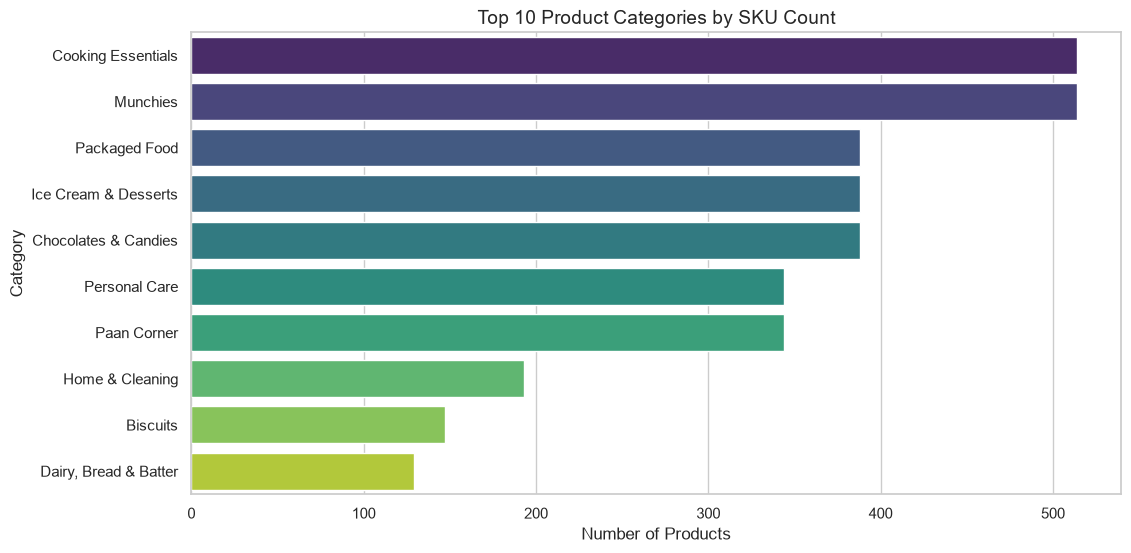

In [4]:
top_categories = df['category'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y=top_categories.index, x=top_categories.values, palette="viridis")
plt.title('Top 10 Product Categories by SKU Count', fontsize=14)
plt.xlabel('Number of Products')
plt.ylabel('Category')
plt.show()

### 3.2 Distribution of Discount Percentages
Are most products heavily discounted, or just slightly? Let's look at the distribution.

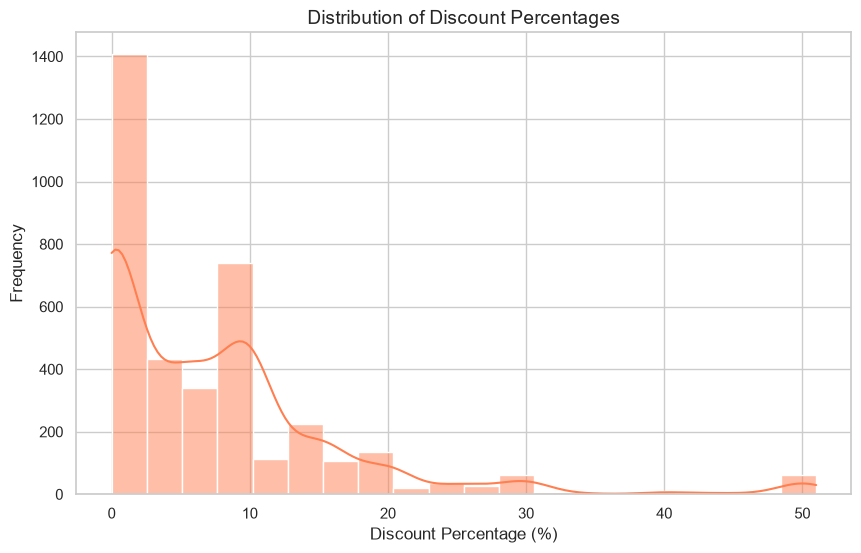

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['discountPercent'], bins=20, kde=True, color='coral')
plt.title('Distribution of Discount Percentages', fontsize=14)
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Frequency')
plt.show()

### 3.3 Out-of-Stock Rate per Category
Let's see which of the top 10 categories have the highest proportion of out-of-stock items.

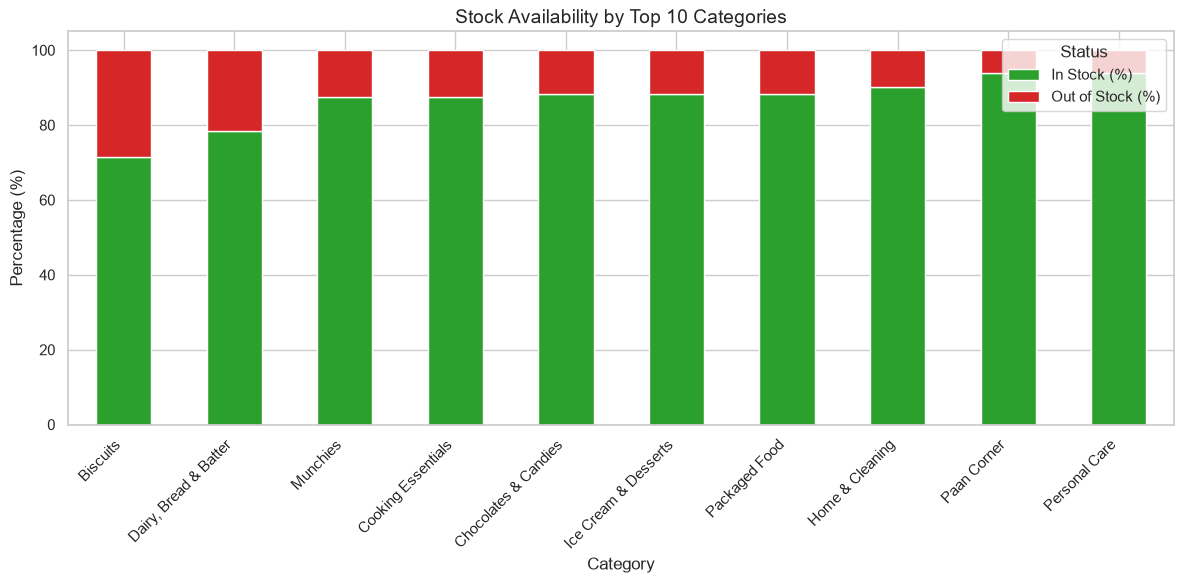

In [6]:
# Filter for top 10 categories
top_10_cats = df['category'].value_counts().head(10).index
df_top10 = df[df['category'].isin(top_10_cats)]

# Calculate out of stock percentages
oos_stats = df_top10.groupby('category')['outOfStock'].value_counts(normalize=True).unstack(fill_value=0) * 100
oos_stats = oos_stats.rename(columns={False: 'In Stock (%)', True: 'Out of Stock (%)'})
oos_stats = oos_stats.sort_values('Out of Stock (%)', ascending=False)

oos_stats.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#2ca02c', '#d62728'])
plt.title('Stock Availability by Top 10 Categories', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Percentage (%)')
plt.legend(title='Status', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.4 Price vs Discount Correlation
Do higher-priced items get larger discounts? We can use a scatter plot to explore this relationship for items under ₹2000 (to remove extreme outliers).

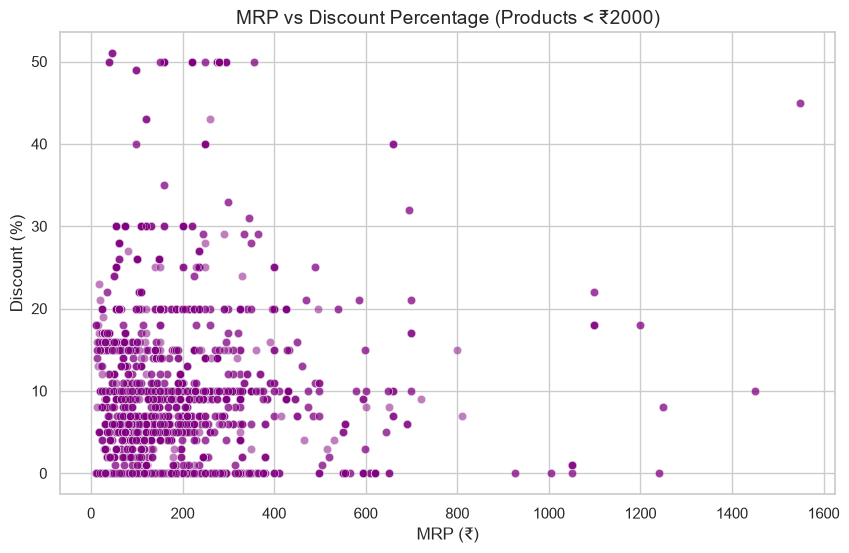

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['mrp'] < 2000], x='mrp', y='discountPercent', alpha=0.5, color='purple')
plt.title('MRP vs Discount Percentage (Products < ₹2000)', fontsize=14)
plt.xlabel('MRP (₹)')
plt.ylabel('Discount (%)')
plt.show()